# TASK #1: UNDERSTAND THE PROBLEM STATEMENT AND BUSINESS CASE

![alt text](Operation_Department_Png/download.png)

![alt text](Operation_Department_Png/download_1.png)

![alt text](Operation_Department_Png/download_2.png)

# TASK #2: IMPORT LIBRARIES AND DATASET

In [2]:
# This is a custom dataset that contains covid-19 x-ray images, viral pneumonia x-ray images, bacterial pneumonia x-ray iamges and normal person x-ray images.
# Each class contains 133 images.

import os
import cv2
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, optimizers
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import Input, Add, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
# Specify training data directory
X_Ray_Directory = 'Dataset'

In [4]:
# List the folders in the directory
os.listdir(X_Ray_Directory)

['.DS_Store1', '0', '1', '2', '3']

In [5]:
# Use image generator to generate tensor images data and normalize them
# Use 20% of the data for cross-validation
image_generator = ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [6]:
# Generate batches of 40 images
# Total number of images is 133*4 = 532 images
# Training is 428 (80%) and validation is 104 (20%)
# Perform shuffling and image resizing

train_generator = image_generator.flow_from_directory(batch_size=40, directory=X_Ray_Directory, shuffle=True,
                                                      target_size=(256,256),class_mode='categorical', subset='training')

Found 428 images belonging to 4 classes.


In [7]:
validation_generator = image_generator.flow_from_directory(batch_size=40, directory=X_Ray_Directory, shuffle=True,
                                                      target_size=(256,256),class_mode='categorical', subset='validation')

Found 104 images belonging to 4 classes.


In [9]:
# Generate a batch of 40 images and labels
train_images, train_labels = next(train_generator)

In [10]:
train_images.shape

(40, 256, 256, 3)

In [11]:
train_labels.shape

(40, 4)

In [12]:
train_labels

array([[0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.]],

In [14]:
# labels Translator
label_names = {0: 'Covid19', 1: 'Normal', 2: 'Viral Pneumonia', 3: 'Bacterial Pneumonia'}

# TASK #3: VISUALIZE DATASET 

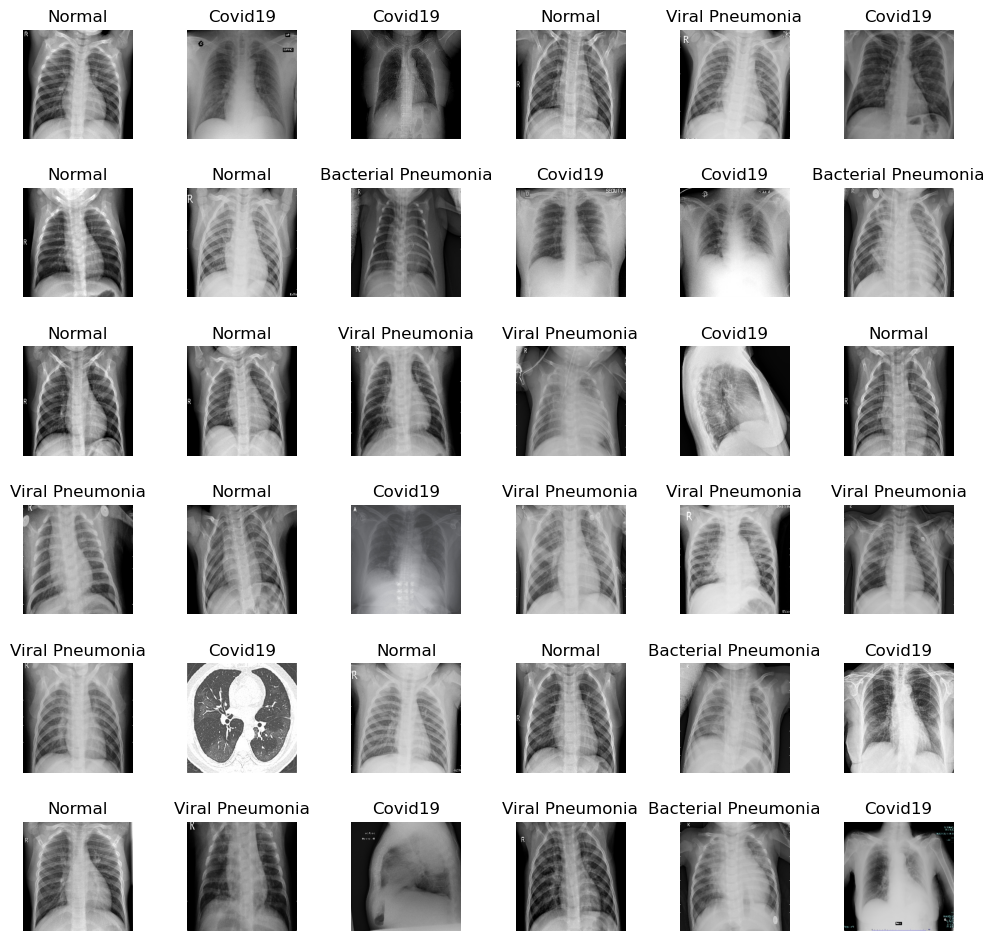

In [ ]:
L = 6
W = 6

fig, axes = plt.subplots(L, W, figsize=(12,12))
axes = axes.ravel()

for i in np.arange(0, L * W):
    axes[i].imshow(train_images[i])
    axes[i].set_title(label_names[np.argmax(train_labels[i])])
    axes[i].axis('off')

plt.subplots_adjust(wspace= 0.5)

# TASK #4: IMPORT MODEL WITH PRETRAINED WEIGHTS 

In [16]:
basemodel = ResNet50(weights= 'imagenet', include_top= False, input_tensor= Input(shape= (256, 256,3)))

In [17]:
basemodel.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [18]:
# freezing layers in the model
for layer in basemodel.layers[:-10]:
    layers.trainable = False

# TASK #5: BUILD AND TRAIN DEEP LEARNING MODEL

In [19]:
headmodel = basemodel.output
headmodel = AveragePooling2D(pool_size=(4,4))(headmodel)
headmodel = Flatten ( name = 'flatten')(headmodel)
headmodel = Dense(256, activation='relu')(headmodel)
headmodel = Dropout(0.3) (headmodel)
headmodel = Dense(256, activation='relu')(headmodel)
headmodel = Dropout(0.3) (headmodel)
headmodel = Dense(4, activation='softmax')(headmodel)

In [20]:
model = Model(inputs = basemodel.input, outputs=headmodel)

In [21]:
model.compile(loss= 'categorical_crossentropy', optimizer= optimizers.RMSprop(learning_rate= 1e-4), metrics=[ 'accuracy'])

In [22]:
# using early stopping to exit training when validation loss is not decreasing after certain number of epochs (patience)
earlystopping = EarlyStopping(monitor= 'val_loss', mode = 'min', patience= 20)

# save the best model with lower validation loss
checkpointer = ModelCheckpoint(filepath= 'weights.h5', verbose= 1, save_best_only=True)

In [23]:
train_generator = image_generator.flow_from_directory(batch_size= 4, directory= X_Ray_Directory, shuffle=True,
                                                      target_size= (256, 256), class_mode= 'categorical', subset= 'training')


validation_generator = image_generator.flow_from_directory(batch_size= 4, directory= X_Ray_Directory, shuffle=True,
                                                      target_size= (256, 256), class_mode= 'categorical', subset= 'validation')

Found 428 images belonging to 4 classes.


Found 104 images belonging to 4 classes.


In [24]:

history = model.fit(train_generator, epochs = 25, validation_data= validation_generator, callbacks = [checkpointer, earlystopping])

Epoch 1/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5298 - loss: 1.2424
Epoch 1: val_loss improved from None to 6.43583, saving model to weights.h5



Epoch 1: finished saving model to weights.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - accuracy: 0.6846 - loss: 0.9125 - val_accuracy: 0.2500 - val_loss: 6.4358
Epoch 2/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8195 - loss: 0.5569
Epoch 2: val_loss improved from 6.43583 to 2.55826, saving model to weights.h5



Epoch 2: finished saving model to weights.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.8621 - loss: 0.4316 - val_accuracy: 0.2500 - val_loss: 2.5583
Epoch 3/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8951 - loss: 0.3866
Epoch 3: val_loss did not improve from 2.55826
107/107 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.8738 - loss: 0.4327 - val_accuracy: 0.2500 - val_loss: 12.3575
Epoch 4/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9469 - loss: 0.2050
Epoch 4: val_loss did not improve from 2.55826
107/107 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.9416 - loss: 0.2889 - val_accuracy: 0.2500 - val_loss: 22.2221
Epoch 5/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9541 - loss: 0.1801
Epoch 5: val_loss did not improve from 2.55826
107/107 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - accuracy: 0.9463 - loss: 0.2066 - val_accuracy: 0.2500 - val_loss: 19.9213
Epoch 6/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9505 - loss: 0.191


Epoch 9: finished saving model to weights.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.9883 - loss: 0.0795 - val_accuracy: 0.8365 - val_loss: 0.5918
Epoch 10/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9956 - loss: 0.0071
Epoch 10: val_loss did not improve from 0.59176
107/107 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.9977 - loss: 0.0072 - val_accuracy: 0.8654 - val_loss: 0.9390
Epoch 11/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9993 - loss: 0.0041
Epoch 11: val_loss did not improve from 0.59176
107/107 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.9977 - loss: 0.0046 - val_accuracy: 0.8654 - val_loss: 1.8039
Epoch 12/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9987 - loss: 0.0104
Epoch 12: val_loss did not improve from 0.59176
107/107 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.9953 - loss: 0.0135 - val_accuracy: 0.7788 - val_loss: 2.4367
Epoch 13/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9840 - loss: 0


Epoch 19: finished saving model to weights.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.9907 - loss: 0.0662 - val_accuracy: 0.9615 - val_loss: 0.5642
Epoch 20/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 8.2733e-04
Epoch 20: val_loss did not improve from 0.56415
107/107 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.9231 - val_loss: 0.7431
Epoch 21/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9839 - loss: 0.0938
Epoch 21: val_loss did not improve from 0.56415
107/107 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - accuracy: 0.9907 - loss: 0.0683 - val_accuracy: 0.9423 - val_loss: 0.7704
Epoch 22/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 7.3883e-04
Epoch 22: val_loss improved from 0.56415 to 0.31387, saving model to weights.h5



Epoch 22: finished saving model to weights.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 1.0000 - loss: 6.6659e-04 - val_accuracy: 0.9231 - val_loss: 0.3139
Epoch 23/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 4.4408e-04
Epoch 23: val_loss did not improve from 0.31387
107/107 ━━━━━━━━━━━━━━━━━━━━ 209s 2s/step - accuracy: 1.0000 - loss: 6.3627e-04 - val_accuracy: 0.9135 - val_loss: 0.3809
Epoch 24/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 1.7213e-05
Epoch 24: val_loss did not improve from 0.31387
107/107 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 1.0000 - loss: 4.0350e-05 - val_accuracy: 0.9519 - val_loss: 0.4907
Epoch 25/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 1.3821e-05
Epoch 25: val_loss did not improve from 0.31387
107/107 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 1.0000 - loss: 1.0403e-05 - val_accuracy: 0.9615 - val_loss: 0.4228


# TASK #6: EVALUATE TRAINED DEEP LEARNING MODEL

In [25]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

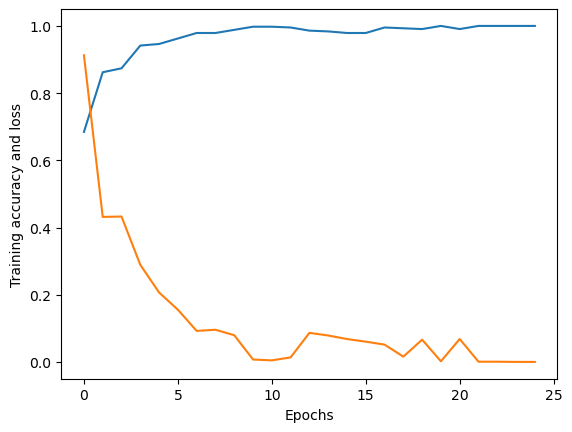

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Training accuracy and loss')

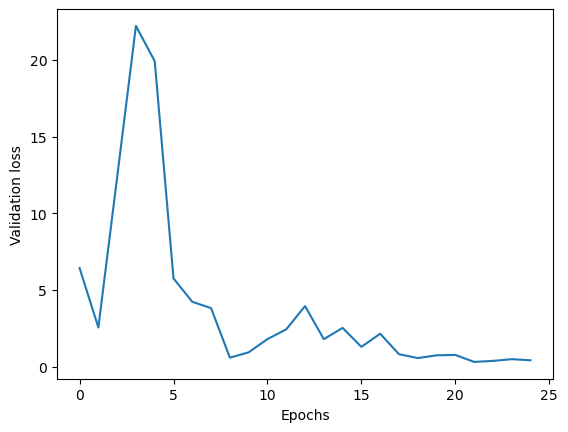

In [ ]:
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Validation loss')

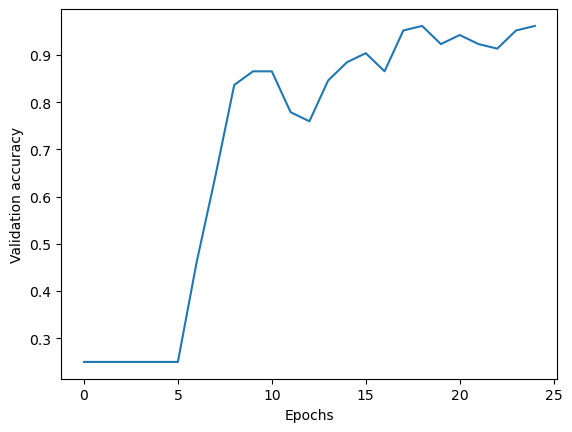

In [ ]:
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Validation accuracy')

In [29]:
test_directory = 'Test'

In [30]:
test_gen = ImageDataGenerator(rescale = 1./255)

test_generator = test_gen.flow_from_directory(batch_size = 40, directory= test_directory, shuffle= True, target_size=(256,256), class_mode= 'categorical')

evaluate = model.evaluate(test_generator, verbose=1)

print(f"Accuracy Test: {evaluate[1]}")

Found 40 images belonging to 4 classes.


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.8000 - loss: 3.1756
Accuracy Test: 0.800000011920929


In [31]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

prediction = []
original = []
image = []

for i in range(len(os.listdir(test_directory))):
    class_dir = os.path.join(test_directory, str(i))
    
    # Check if the directory exists before proceeding
    if os.path.isdir(class_dir):
        for item in os.listdir(class_dir):
            img = cv2.imread(os.path.join(class_dir, item))
            img = cv2.resize(img, (256, 256))
            image.append(img)
            img = img / 255
            img = img.reshape(-1, 256, 256, 3)
            predict = model.predict(img)
            predict = np.argmax(predict)
            prediction.append(predict)
            original.append(i)
    else:
        print(f"Directory {class_dir} is missing or empty.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [32]:
len(original)

40

In [33]:
score = accuracy_score(original, prediction)
print(f"Test Accuracy: {score}")

Test Accuracy: 0.775


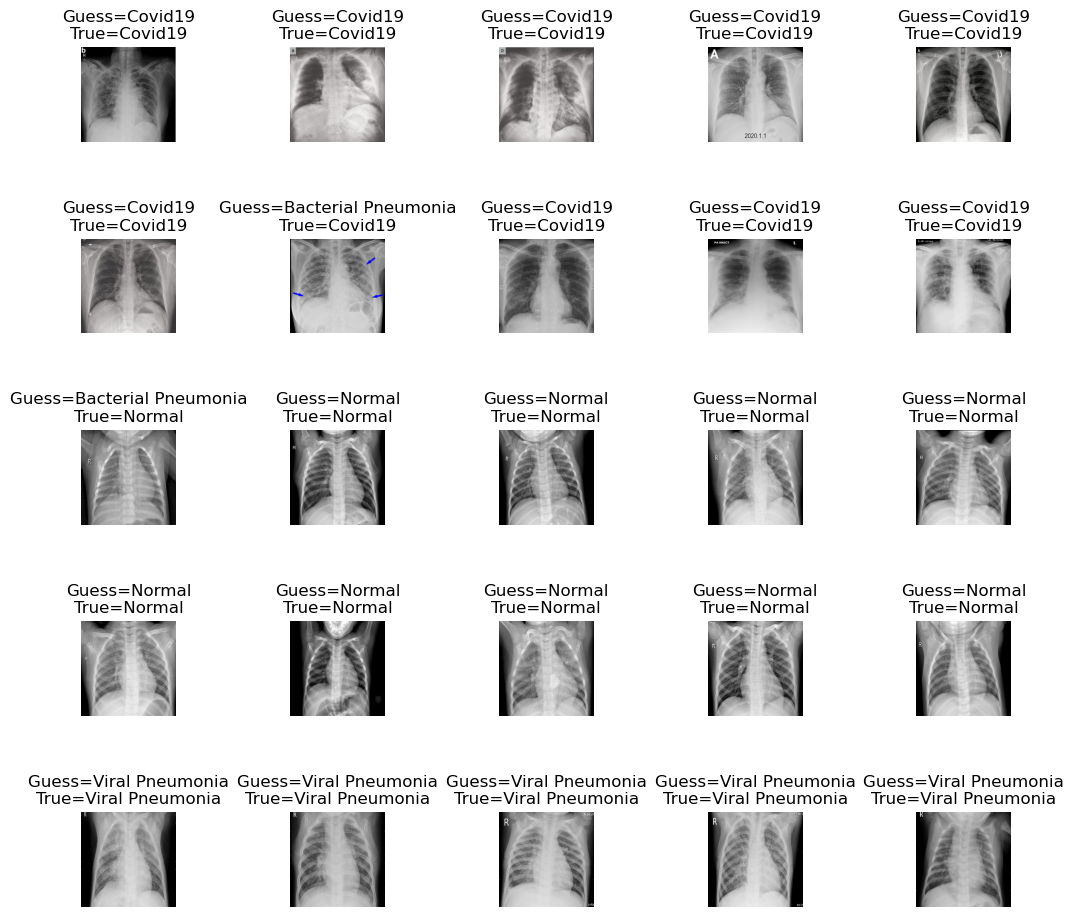

In [ ]:
L = 5
W = 5

fig, axes = plt.subplots(L, W, figsize = (12, 12))
axes = axes.ravel()

for i in np.arange(0, L*W):
    axes[i].imshow(image[i])
    axes[i].set_title(f"Guess={label_names[prediction[i]]}\nTrue={label_names[original[i]]}")
    axes[i].axis('off')

plt.subplots_adjust(wspace = 1.2)

In [35]:
print(classification_report(np.asarray(original), np.asarray(prediction)))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.75      0.90      0.82        10
           2       1.00      0.50      0.67        10
           3       0.62      0.80      0.70        10

    accuracy                           0.78        40
   macro avg       0.82      0.77      0.77        40
weighted avg       0.82      0.78      0.77        40



Text(0.5, 1.0, 'Confusion_matrix')

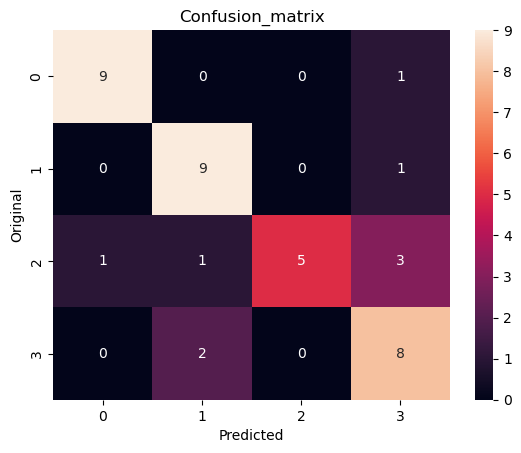

In [37]:
cm = confusion_matrix(np.asarray(original), np.asarray(prediction))
ax = plt.subplot()
sns.heatmap(cm, annot = True, ax = ax)

ax.set_xlabel('Predicted')
ax.set_ylabel('Original')
ax.set_title('Confusion_matrix')

# Well Done!